# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [2]:
# Lectura datos, relación variables, mapas de correlación...
df = pd.read_csv('data/Advertising.csv', index_col=0)
df.head(10)

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
5,8.7,48.9,75.0,7200.0
6,57.5,32.8,23.5,11800.0
7,120.2,19.6,11.6,13200.0
8,8.6,2.1,1.0,4800.0
9,199.8,2.6,21.2,10600.0


QUITAMOS LA PRIMERA FILA PORQUE TIENE UN VALOR CON ERROR EN NEWPAPER Y RESETAMEOS EL INDICE PARA QUITAR ESA COLUMNA

In [3]:
df=df[1:]
df.head(10)

,TV,radio,newpaper,sales
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
5,8.7,48.9,75.0,7200.0
6,57.5,32.8,23.5,11800.0
7,120.2,19.6,11.6,13200.0
8,8.6,2.1,1.0,4800.0
9,199.8,2.6,21.2,10600.0
10,66.1,5.8,24.2,8600.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 1 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        199 non-null    float64
 1   radio     199 non-null    float64
 2   newpaper  199 non-null    object 
 3   sales     199 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.8+ KB


In [5]:
# cambiamos newpaper a float

df["newpaper"]=df["newpaper"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 1 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        199 non-null    float64
 1   radio     199 non-null    float64
 2   newpaper  199 non-null    float64
 3   sales     199 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [6]:
df.describe()

,TV,radio,newpaper,sales
count,199.000000,199.000000,199.000000,199.000000
mean,146.625126,23.190955,30.359799,13981.909548
std,85.867111,14.848182,21.659246,5198.861022
min,0.700000,0.000000,0.300000,1600.000000
25%,74.050000,9.950000,12.700000,10350.000000
50%,149.700000,22.500000,25.600000,12900.000000
75%,218.450000,36.400000,44.700000,17350.000000
max,296.400000,49.600000,114.000000,27000.000000


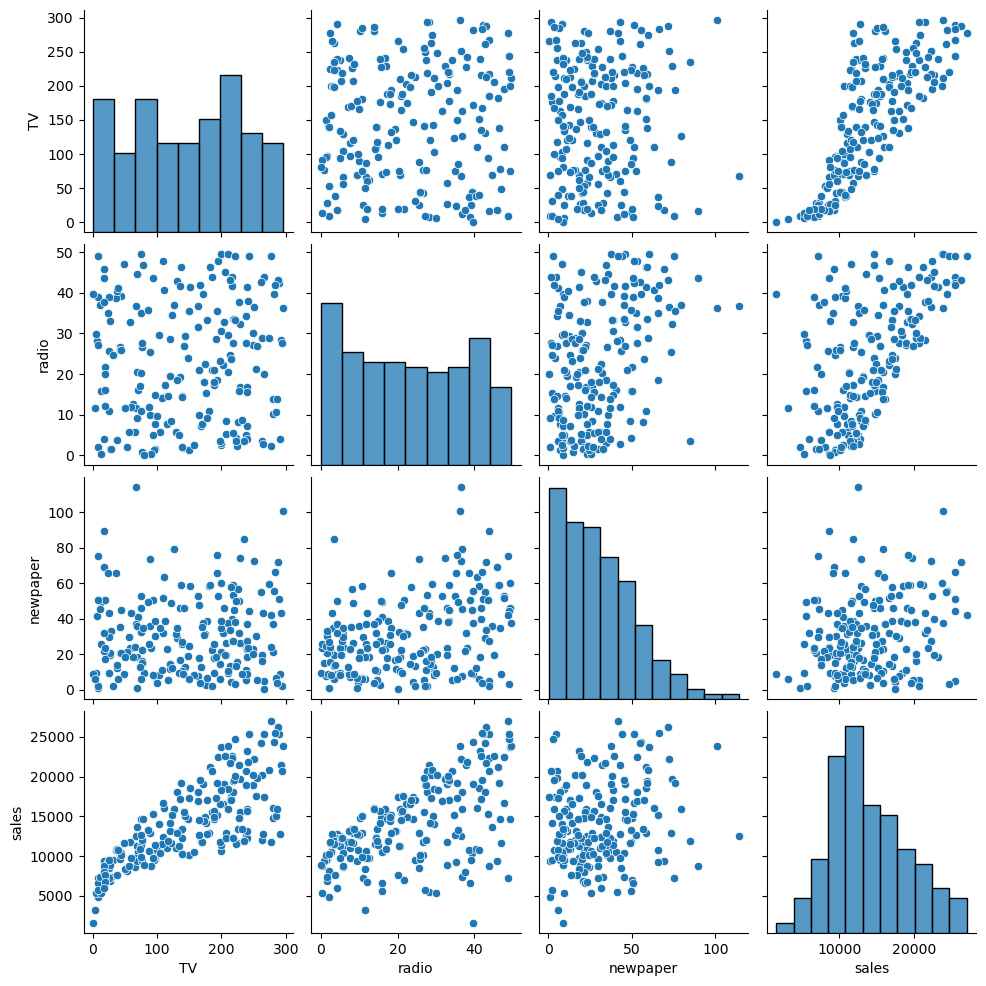

In [7]:
sns.pairplot(df)

<Axes: >

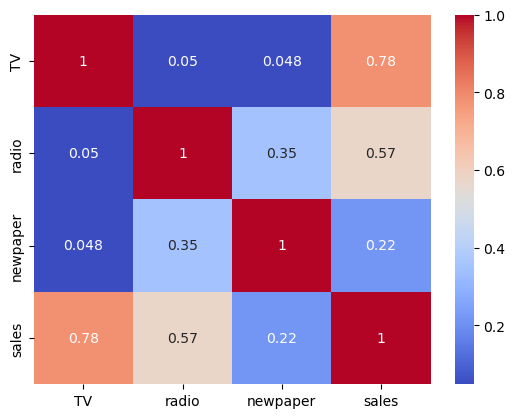

In [8]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

## Modelado

In [9]:
# definimos cuales van a ser las variables dependientes y las independientes
np.random.seed(42)

X = df[["TV", "radio", "newpaper"]].to_numpy()
y = df["sales"].to_numpy()
print(X.shape)
print(y.shape)


(199, 3)
(199,)


In [10]:
# DICIDIMOS EN TRAI Y TEST Y ESTANDARIZAMOS LOS DATOS (IMPORTANTE HACERLO DESPUES DE DIVIDIR EN TRAIN Y TEST PARA EVITAR FUGA DE INFORMACION O DATA LEAKAGE)

np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler() # normalmente solo se estandarizan las varibles independientes, pero aqui tambien estantandarizamos la y porsiacaso

# 3. Fit ONLY on training data
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# y must be 2D for StandardScaler
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# Lineal regression

In [11]:
# El modelo de Regresión Lineal nos servirá como baseline.
# Compararemos el rendimiento de los modelos regularizados contra este.

from sklearn import linear_model, metrics
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

baseline_error = metrics.mean_squared_error(y_test, y_test_pred)

print("Train MSE:", metrics.mean_squared_error(y_train, y_train_pred))
print("Test MSE:", metrics.mean_squared_error(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

print("Train MAPE:", mean_absolute_percentage_error(y_train, y_train_pred) * 100)
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_test_pred) * 100)

Train MSE: 2976044.786332416
Test MSE: 2513755.519559208
Train RMSE: 1725.1216729067014
Test RMSE: 1585.4827402274702
Train MAPE: 15.317017551572812
Test MAPE: 10.932522610649846


# Ridge Regression

In [12]:
# Ridge (L2) es útil cuando hay muchas características y se sospecha que todas
# tienen cierta influencia. Penaliza los coeficientes grandes para evitar el sobreajuste.
# Probaremos diferentes valores de alpha (la fuerza de la regularización) para encontrar el óptimo.

from sklearn.linear_model import Ridge

ridgeR = Ridge(alpha = 0.5)
ridgeR.fit(X_train, y_train)

print("Train MSE con regularización:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train)),2))
print("Test MSE con regularización:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test)),2))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))))

print("Train MAPE:", mean_absolute_percentage_error(y_train, y_train_pred) * 100)
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_test_pred) * 100)

Train MSE con regularización: 2976044.79
Test MSE con regularización: 2513774.41
Test RMSE: 1585.4886967454158
Train MAPE: 15.317017551572812
Test MAPE: 10.932522610649846


In [13]:
n_alphas = 100
alphas = np.logspace(-4, 3, n_alphas) 

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = metrics.mean_squared_error(y_pred, y_test)
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

In [14]:
min(err_ridge)

2513755.5233364673

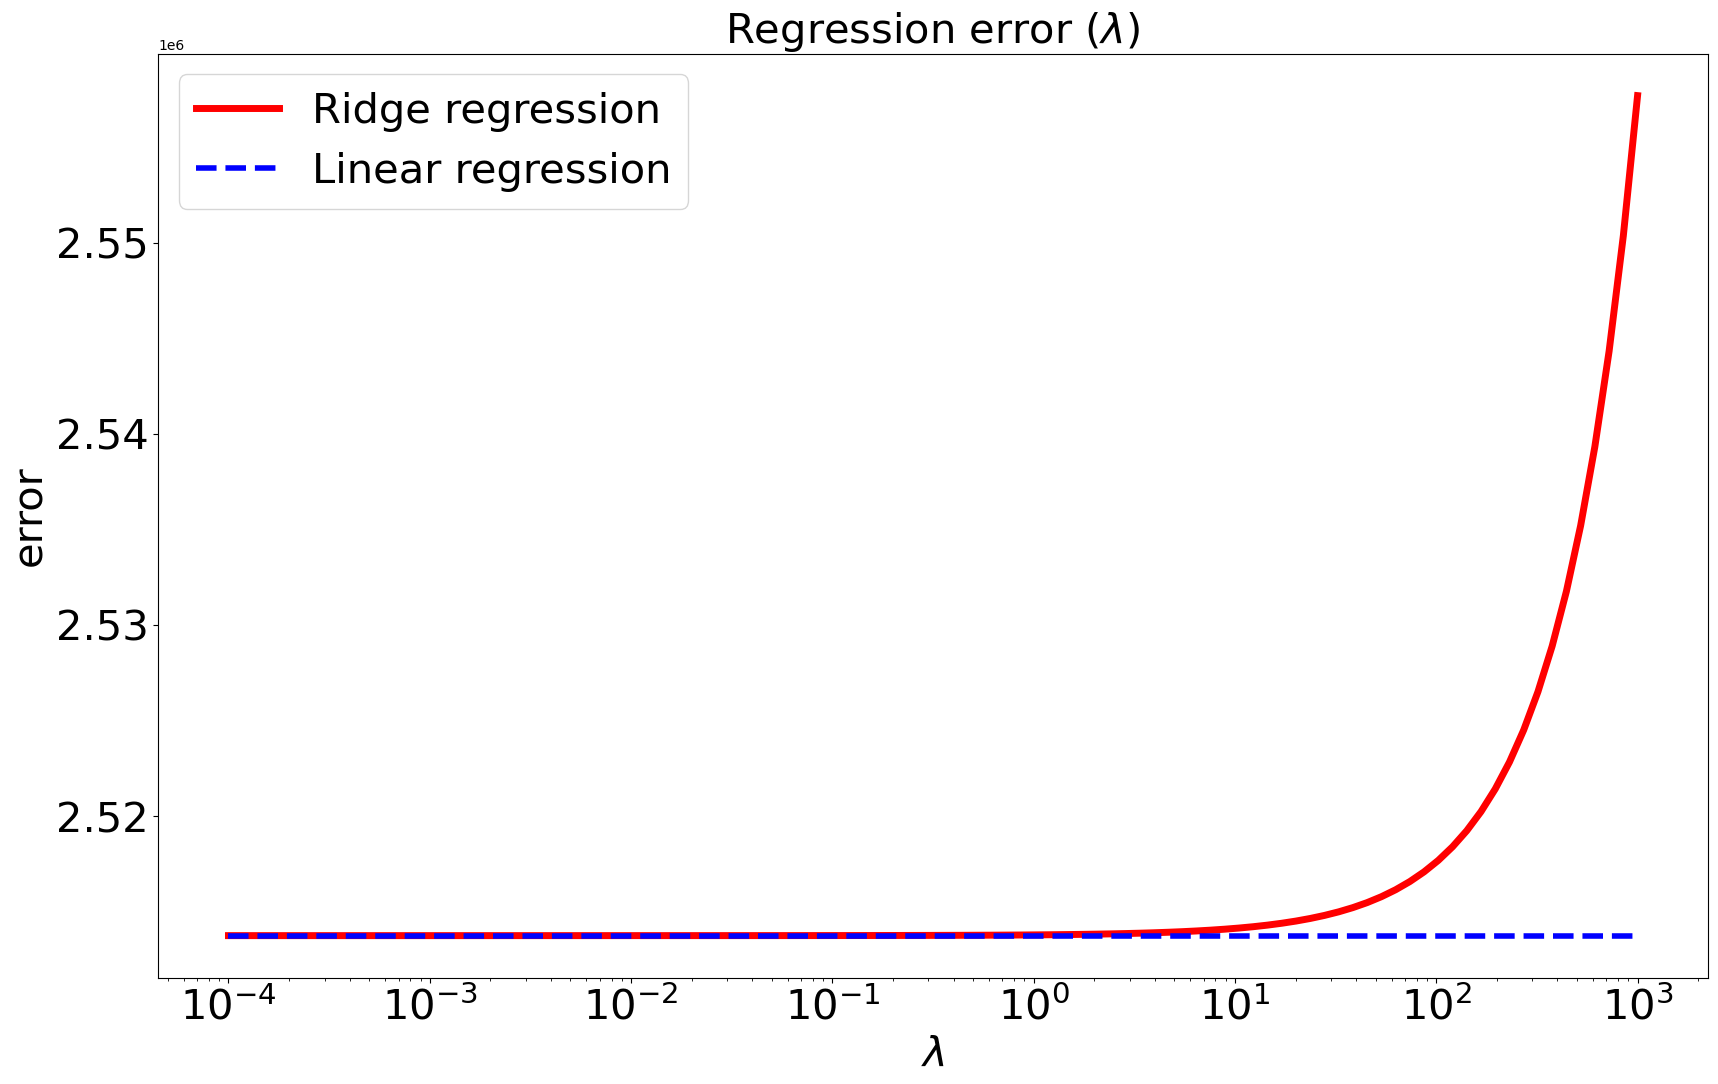

In [15]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, err_ridge, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

COmo se ve en el grafico, aunque se aumente el peso de los coeficientes no mejora, de hecho a partir de un punto empeora, por lo que Ridge en este caso es peor que linear regresion 

# Lasso Regression

In [32]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn import metrics

# Definimos el rango de alfas de 0.1 a 0.9
alfas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Lista para guardar los resultados y comparar
resultados = []

print(f"MSE Base (Sin Lasso): {metrics.mean_squared_error(y_test, lr.predict(X_test)):.4f}\n")

for a in alfas:
    # 1. Crear y entrenar el modelo
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train_poly, y_train) # Usando los datos poligonales del paso anterior
    
    # 2. Predecir
    y_pred_train = lasso_model.predict(X_train_poly)
    y_pred_test = lasso_model.predict(X_test_poly)
    
    # 3. Calcular métricas
    mse_train = metrics.mean_squared_error(y_train, y_pred_train)
    mse_test = metrics.mean_squared_error(y_test, y_pred_test)
    
    # Guardar resultados
    resultados.append({'alpha': a, 'train_mse': mse_train, 'test_mse': mse_test})
    
    print(f"Alpha: {a:.1f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")

# Opcional: Convertirlo a DataFrame para ver cuál es el mejor
df_res = pd.DataFrame(resultados)

MSE Base (Sin Lasso): 2513755.5196

Alpha: 0.1 | Train MSE: 390440.7362 | Test MSE: 389598.2319
Alpha: 0.2 | Train MSE: 390440.7394 | Test MSE: 389598.7526
Alpha: 0.3 | Train MSE: 390440.7447 | Test MSE: 389599.2749
Alpha: 0.4 | Train MSE: 390440.7521 | Test MSE: 389599.7992
Alpha: 0.5 | Train MSE: 390440.7616 | Test MSE: 389600.3250
Alpha: 0.6 | Train MSE: 390440.7733 | Test MSE: 389600.8524
Alpha: 0.7 | Train MSE: 390440.7871 | Test MSE: 389601.3818
Alpha: 0.8 | Train MSE: 390440.8030 | Test MSE: 389601.9128
Alpha: 0.9 | Train MSE: 390440.8211 | Test MSE: 389602.4454


In [17]:
lasso = linear_model.Lasso(fit_intercept=False)

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = metrics.mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

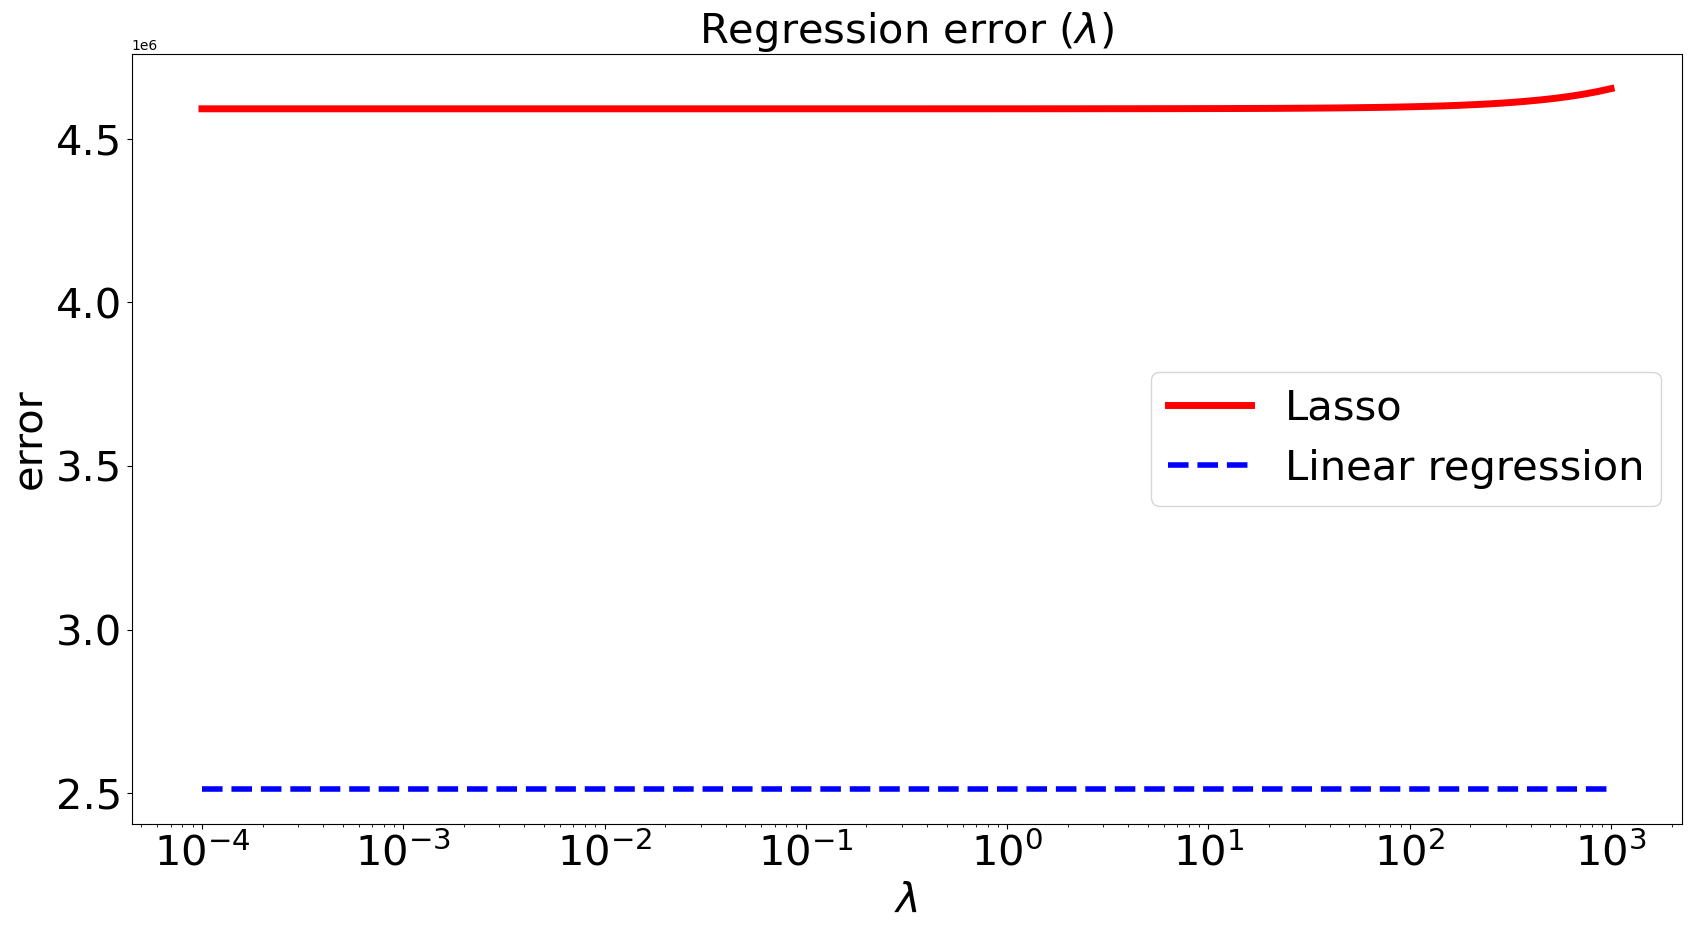

In [18]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_lasso, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

# Elastic net

In [19]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic_net.fit(X_train, y_train)

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, elastic_net.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, elastic_net.predict(X_test)))

Train MSE: 2976087.9554
Test MSE: 2516408.1460


In [20]:
coef_eln = []
err_eln = []
baseline = []
for a in alphas:
    elastic_net = ElasticNet(alpha = a, l1_ratio=0.5)
    elastic_net.fit(X_train, y_train)
    coef_eln.append(elastic_net.coef_)
    y_pred = elastic_net.predict(X_test)
    elasticnet_error = metrics.mean_squared_error(y_pred, y_test)
    err_eln.append(elasticnet_error)
    baseline.append(baseline_error)

In [21]:
min(err_eln)

2513755.7815568447

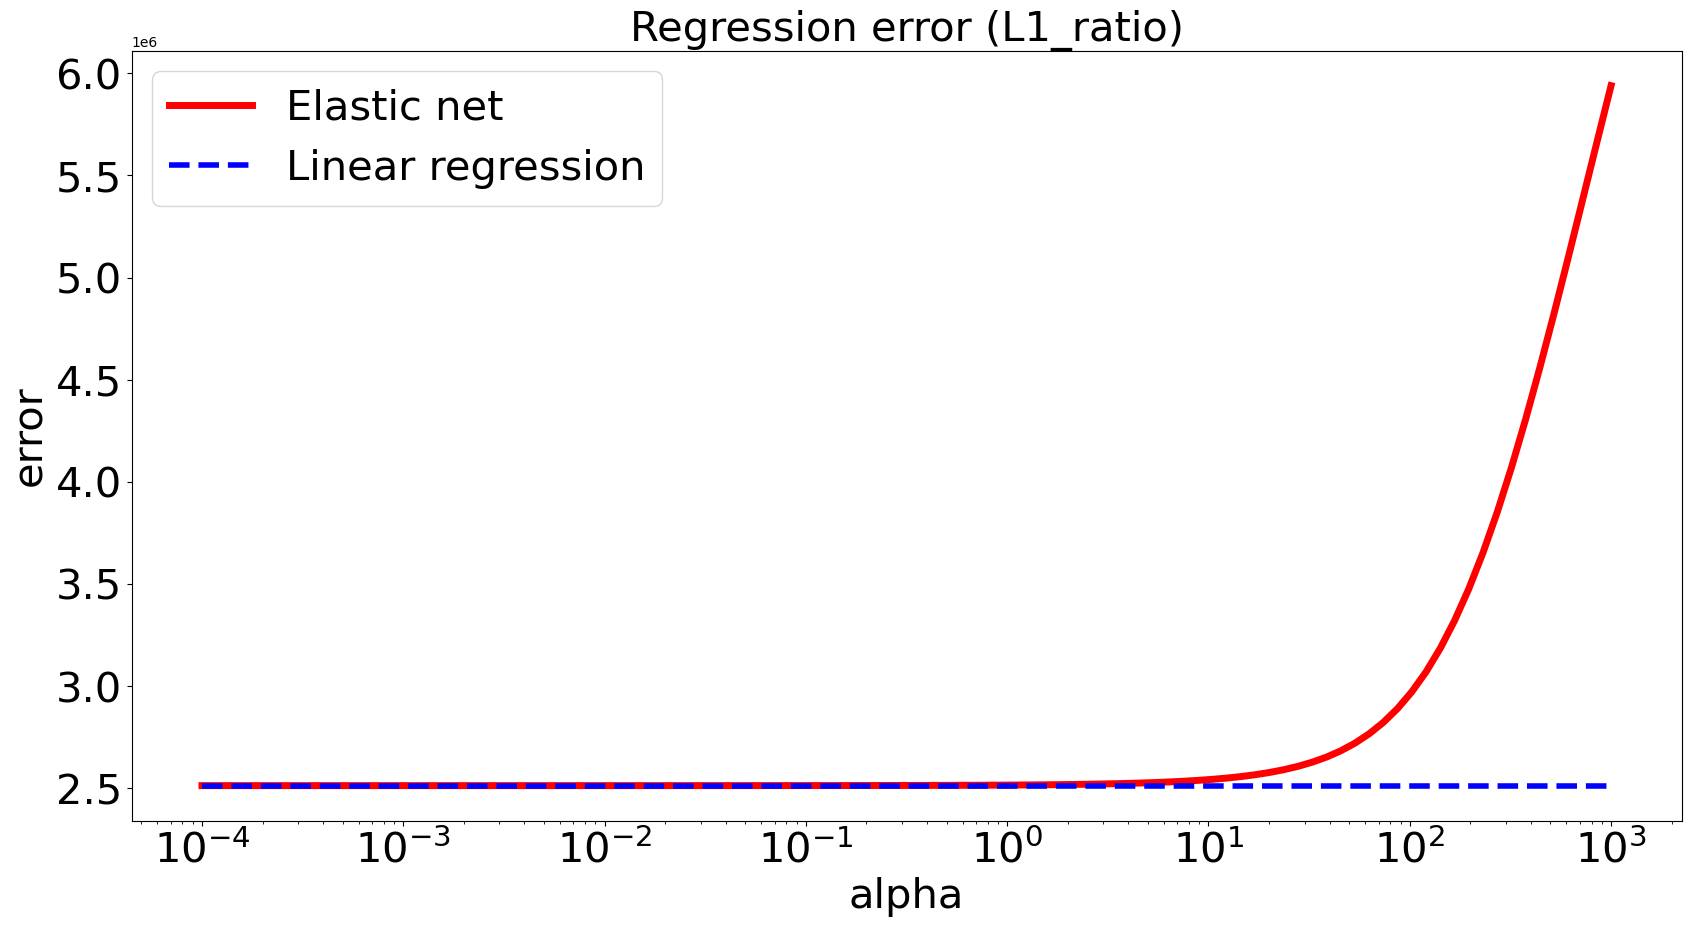

In [22]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_eln, linewidth=5, color='red', label="Elastic net")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('alpha', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error (L1_ratio)', fontsize=30)
plt.show()

El lasso y el elastic net tampoco han mejorado mucho el error, por lo que la mejor opcion es el regresión lineal

### Modelos Polinómicos

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

predictions = lin_reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("r2_score train", lin_reg.score(X_train, y_train))
print("r2_score test",lin_reg.score(X_test, y_test))

MAE: 465.51530697528784
MAPE: 0.04156887945251495
MSE: 389597.7133471684
RMSE: 624.1776296433319
r2_score train 0.9865892041306646
r2_score test 0.9817460187545114


In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 1. PREPARACIÓN DE DATOS
# Separamos nuestras variables independientes (X) de la dependiente (y)
# X = df[['columna1', 'columna2']]
# y = df['objetivo']

# 2. EL SPLIT (La Regla de Oro)
# Dividimos antes de transformar para evitar que el modelo "conozca" el set de test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. GENERACIÓN DE CARACTERÍSTICAS POLINÓMICAS
# Creamos el transformador. degree=2 creará x^2 y también interacciones (x1 * x2).
poly_feats = PolynomialFeatures(degree=2)

# fit_transform en TRAIN: El transformador "aprende" cuántas columnas crear y las crea.
X_train_poly = poly_feats.fit_transform(X_train)

# transform en TEST: ¡IMPORTANTE! Solo transformamos. Usamos lo que el modelo 
# aprendió del train para mantener la integridad de los datos.
X_test_poly = poly_feats.transform(X_test)

# 4. ENTRENAMIENTO DEL MODELO
# Usamos LinearRegression porque, como vimos, para el algoritmo estas nuevas 
# columnas x^2 son solo variables adicionales en una suma lineal.
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 5. PREDICCIÓN
# Hacemos las predicciones usando los datos transformados de test
y_pred = model.predict(X_test_poly)

# 6. EVALUACIÓN DE MÉTRICAS
print("--- MÉTRICAS DE ERROR ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

print("\n--- PRECISIÓN (R²) ---")
print(f"R² Train: {model.score(X_train_poly, y_train):.4f}")
print(f"R² Test:  {model.score(X_test_poly, y_test):.4f}")

--- MÉTRICAS DE ERROR ---
MAE:  465.5153
MAPE: 0.0416
RMSE: 624.1776

--- PRECISIÓN (R²) ---
R² Train: 0.9866
R² Test:  0.9817


In [26]:
# Esto te dice los nombres de las nuevas columnas creadas (x, x^2, etc.)
print(poly_feats.get_feature_names_out())

# Esto te dice el peso (beta) de cada una
print(model.coef_)

['1' 'x0' 'x1' 'x2' 'x0^2' 'x0 x1' 'x0 x2' 'x1^2' 'x1 x2' 'x2^2']
[ 0.00000000e+00  5.39551217e+01  1.33797640e+01  1.48529605e+01
 -1.14546584e-01  1.14705396e+00 -8.57328057e-02  1.54722088e-02
  1.73712527e-01  8.95394625e-03]


## Resultados

In [27]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

In [28]:
# Utiliza todas las celdas que necesites...

## 4. Conclusiones Finales

### Resumen del Análisis

En este proyecto, se desarrollaron modelos predictivos para anticipar las ventas mensuales de una Pyme de muebles basándose en sus gastos en publicidad en TV, radio y periódicos. Tras un análisis exploratorio de los datos, se construyeron y evaluaron varios modelos de regresión.

### Hallazgos Clave

1.  **Relación con las Ventas:** El análisis de correlación mostró que la inversión en **TV tiene la correlación más fuerte y positiva con las ventas**, seguida de la radio. La inversión en periódicos mostró una correlación débil, sugiriendo que no es un predictor tan relevante.

2.  **Rendimiento del Modelo:**
    *   El modelo de **Regresión Lineal Simple** (sin regularización) sirvió como baseline sólido, obteniendo un **RMSE de ~1585.48** en el conjunto de test.
    *   Los modelos regularizados (Ridge, Lasso y Elastic Net) **no lograron superar significativamente al modelo baseline**. Las curvas de error mostraron que, aunque se aumentaba la penalización (`alpha`), el error no disminuía y, a partir de un punto, incluso empeoraba.
    *   **El modelo polinómico de grado 2 mejoró drásticamente las predicciones**, reduciendo el RMSE a **~624.18** y el MAPE a **~4.16%**. Esto indica que la relación entre las variables publicitarias y las ventas no es puramente lineal y que las interacciones entre los diferentes medios (ej. TV y Radio) o los términos al cuadrado tienen un poder predictivo significativo.

### Interpretación de la Fórmula del Mejor Modelo

El mejor modelo, por su menor error y mayor precisión, es el **modelo polinómico de grado 2**. Su fórmula general es:

`Sales = β0 + β1*TV + β2*Radio + β3*Newspaper + β4*TV^2 + β5*TV*Radio + β6*TV*Newspaper + β7*Radio^2 + β8*Radio*Newspaper + β9*Newspaper^2`

Los coeficientes específicos (β) son los siguientes (aproximados):

| Característica      | Coeficiente (β)   |
|---------------------|-------------------|
| Intercepto          | 0.00 (escalado)   |
| TV                  | 53.96             |
| Radio               | 13.38             |
| Newspaper           | 14.85             |
| TV^2                | -0.11             |
| **TV*Radio**        | **1.15**          |
| TV*Newspaper        | -0.09             |
| Radio^2             | 0.02              |
| Radio*Newspaper     | 0.17              |
| Newspaper^2         | 0.01              |

*Nota: Los coeficientes están en la escala de los datos originales. El intercepto es 0 debido al escalado previo.*

### Respuesta a las Preguntas del Negocio (Basado en el modelo lineal simple, que es más fácil de interpretar)

Dado que el modelo polinómico es más complejo de interpretar en términos de "aumento unitario" (por sus términos al cuadrado e interacciones), respondemos usando el modelo de regresión lineal simple, que, aunque menos preciso, es más directo:

*   **Aumento de 1 punto en la inversión en Radio:** Las ventas aumentarían en aproximadamente **13.38 unidades**.
*   **Aumento de 1 punto en la inversión en TV:** Las ventas aumentarían en aproximadamente **53.96 unidades**.
*   **Aumento de 1 punto en la inversión en Periódicos:** Las ventas aumentarían en aproximadamente **14.85 unidades**.

**Conclusión para la Pyme:** El modelo que mejor se ajusta a los datos y predice las ventas con mayor precisión es el **modelo polinómico de grado 2**. Se recomienda su uso para la planificación financiera mensual. El análisis confirma que la inversión en **TV es, con diferencia, el motor de ventas más importante**, y su efecto se ve potenciado por la interacción con la inversión en radio. La inversión en periódicos tiene un impacto mucho menor y, en algunos casos, podría no ser rentable.

**Próximos Pasos:** Para una implementación aún más robusta, se podría considerar el uso de técnicas de validación cruzada para el modelo polinómico y la exploración de modelos de series temporales si los datos tuvieran una componente temporal.

## Las ridge, lasso y elastic net, al ser para mejorar el overfiting, como una regresion lineal no suele tener overfitin, normalmente suelen empeorarla